In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from matplotlib.ticker import FixedLocator
from matplotlib.lines import Line2D
import scienceplots

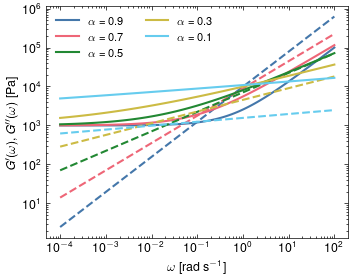

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use(['science', 'nature', 'bright'])

# ---------------- Function to compute G' and G'' ----------------
def calculate_Gpfun_Gppfun(G, V, alpha, beta, omega):
    omega_alpha = omega ** alpha
    cos_alpha_half = np.cos(np.pi * alpha / 2)
    sin_alpha_half = np.sin(np.pi * alpha / 2)

    Gpfun = V * omega_alpha * cos_alpha_half + G
    Gppfun = V * omega_alpha * sin_alpha_half

    return Gpfun, Gppfun

# ---------------- Parameters ----------------
G_fixed = 1000
V_fixed = 10000
omega = np.logspace(-4, 2, 100)

alpha_values = [0.9, 0.7, 0.5, 0.3, 0.1]
beta_values = [0, 0, 0, 0, 0]

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ---------------- Create figure ----------------
plt.figure(figsize=(3.640625, 2.9))

for idx, (alpha, beta) in enumerate(zip(alpha_values, beta_values)):
    color = color_cycle[idx % len(color_cycle)]
    Gpfun, Gppfun = calculate_Gpfun_Gppfun(G_fixed, V_fixed, alpha, beta, omega)
    plt.plot(omega, Gpfun, '-', lw=1.5, label=f'$\\alpha={alpha}$', color=color)
    plt.plot(omega, Gppfun, '--', lw=1.5, color=color)

# ---------------- Customize plot ----------------
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\omega~\\mathrm{[rad~s^{-1}]}$', fontsize=9)
plt.ylabel('$G^{\\prime}(\omega), G^{\\prime\\prime}(\omega)~\\mathrm{[Pa]}$', fontsize=9)
plt.minorticks_on()
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tick_params(axis='y', which='both', direction='in')
plt.tick_params(axis='x', which='both', direction='in')
plt.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()

# ---------------- Ensure output folder exists ----------------
out_dir = "../figures/main/theoretical_model_responses"
os.makedirs(out_dir, exist_ok=True)

# ---------------- Save figure ----------------
out_file = os.path.join(out_dir, "fig_results_calibration_fkvs.pdf")
plt.savefig(out_file, dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()


/tmp/ipykernel_57491/2552450673.py:22: DeprecationWarning: OscillationEvaluator will be deprecated and will be removed in future versions. Please use SAOSEvaluator instead.
  evaluator = OscillationEvaluator(model=model)


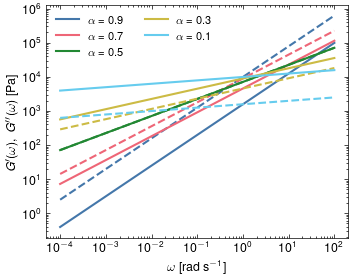

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pyRheo.oscillation_evaluator import OscillationEvaluator
from matplotlib.ticker import LogLocator
import os

plt.style.use(['science', 'nature', 'bright'])

# ---------------- Parameters ----------------
omega = np.logspace(-4, 2, 15)
model = "SpringPot"
V = 1e4
alpha_values = [0.9, 0.7, 0.5, 0.3, 0.1]

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ---------------- Create figure ----------------
plt.figure(figsize=(3.640625, 2.9))

for i, alpha in enumerate(alpha_values):
    params = [V, alpha]
    evaluator = OscillationEvaluator(model=model)
    
    G_prime, G_double_prime = evaluator.compute_model(params, omega)
    
    color = color_cycle[i % len(color_cycle)]
    
    plt.plot(omega, G_prime, '-', lw=1.5, color=color, label=f'$\\alpha$ = {alpha}')
    plt.plot(omega, G_double_prime, '--', lw=1.5, color=color)

# ---------------- Customize plot ----------------
plt.xscale("log")
plt.yscale("log")
plt.xlabel('$\\omega~\\mathrm{[rad~s^{-1}]}$', fontsize=9)
plt.ylabel('$G^{\\prime}(\\omega),~G^{\\prime\\prime}(\\omega)~\\mathrm{[Pa]}$', fontsize=9)
plt.minorticks_on()
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tick_params(axis='y', which='both', direction='in')
plt.tick_params(axis='x', which='both', direction='in')
plt.legend(fontsize=8, loc='upper left', ncol=2)
plt.tight_layout()

# ---------------- Ensure output folder exists ----------------
out_dir = "../figures/main/theoretical_model_responses"
os.makedirs(out_dir, exist_ok=True)

# ---------------- Save figure ----------------
out_file = os.path.join(out_dir, "fig_results_calibration_sp.pdf")
plt.savefig(out_file, dpi=1200, bbox_inches='tight', pad_inches=0.1)
plt.show()
